# Блок 1. Обоснование темы

## Задание 1.1

Придумайте непрерывную зависимую (целевую) переменную и эндогенную бинарную переменную воздействия. Обоснуйте, почему переменная воздействия может быть эндогенной и, в соответствии с приведенным обоснованием, создайте хотя бы одну дополнительную ненаблюдаемую переменную, которая коррелирует и с целевой переменной, и с переменной воздействия.

### Ответ

В работе изучается влияние премиум-подписки на сервис доставки на месячные траты клиента внутри платформы доставки. Содержательно речь идет о подписке, которая снижает для клиента транзакционные издержки заказа: доставка становится дешевле, быстрее или удобнее, а дополнительные привилегии делают повторные заказы менее затратными с точки зрения денег и времени.

Зависимая переменная исследования - `monthly_spending`, то есть месячные траты клиента в сервисе доставки. Это непрерывная денежная величина: она отражает общий объем покупок клиента за месяц и поэтому подходит для задач регрессии и оценки эффектов воздействия. В обозначениях ниже это $Y_i$.

Переменная воздействия - `premium_subscription`, бинарный индикатор оформления премиум-подписки. Значение `1` означает, что клиент оформил подписку, значение `0` - что не оформил. В обозначениях ниже это $D_i \in \{0,1\}$.

Премиум-подписка не назначается клиентам случайно: клиент сам принимает решение, оформлять ее или нет. Поэтому простое сравнение средних трат подписчиков и неподписчиков не дает причинный эффект подписки. Более активные клиенты могут заранее понимать, что будут часто пользоваться доставкой, и поэтому чаще оформлять подписку. В таком случае высокие траты после оформления подписки частично объясняются не самой подпиской, а исходной склонностью клиента часто покупать онлайн.

Для отражения этой проблемы в процессе генерации вводится ненаблюдаемая переменная `online_preference` - склонность клиента к онлайн-покупкам. Она не включается в итоговый набор признаков, но участвует в генерации данных. Клиенты с высокой `online_preference` одновременно чаще оформляют премиум-подписку и больше тратят в сервисе доставки. Именно такая скрытая склонность создает эндогенность: `premium_subscription` коррелирует с ненаблюдаемым фактором, который также влияет на `monthly_spending`.

Формально причинная история задается так:

$$OnlinePreference_i \rightarrow D_i, \quad OnlinePreference_i \rightarrow Y_i.$$

В терминах эконометрики возникает самоотбор в воздействие, а наивная разница средних между подписчиками и неподписчиками смешивает причинный эффект подписки и различия в типах клиентов.

## Задание 1.2

Опишите, для чего может быть полезно изучение влияния переменной воздействия на зависимую переменную. В частности, укажите, как эта информация может быть использована бизнесом или государственными органами.

### Ответ

Для бизнеса оценка эффекта премиум-подписки на месячные траты нужна для принятия решений о дизайне подписочной программы. Если подписка действительно увеличивает траты, платформа может обосновать инвестиции в бесплатную доставку, персональные предложения, пробные периоды и удержание подписчиков. При этом важно отличать реальный прирост от самоотбора: если подписку оформляют только клиенты, которые и так много тратили бы, то агрессивное продвижение подписки может быть менее прибыльным, чем кажется по простому сравнению средних.

Результаты такого исследования могут использоваться для расчета окупаемости премиум-подписки и бесплатных пробных периодов, выбора сегментов клиентов для показа предложения о подписке, оценки того, увеличивает ли подписка общий объем заказов или только перераспределяет уже существующие покупки, настройки ценовой политики и анализа риска каннибализации выручки от доставки.

Для государственных органов и регуляторов такая тема также имеет значение. Подписочные модели могут усиливать рыночную власть крупных платформ, менять потребительское поведение и создавать эффекты привязки клиента к одному сервису. Поэтому причинная оценка влияния подписки полезна для анализа конкуренции на цифровых рынках, оценки прозрачности подписочных условий и изучения того, как платформенные механики влияют на расходы домохозяйств.

## Задание 1.3

Обоснуйте наличие причинно-следственной связи между зависимой переменной и переменной воздействия. Кратко опишите результаты не менее двух предшествующих исследований из научной литературы, подкрепляющих ваши предположения. Критически оцените методологию этих работ и объясните, в чем преимущества и недостатки применяемых вами методов по сравнению с теми, что использовались в этих исследованиях.

### Ответ

Предполагаемая причинная связь состоит в том, что премиум-подписка снижает предельную стоимость дополнительного заказа и делает использование сервиса более удобным. После оплаты подписки клиент может воспринимать каждую следующую доставку как более дешевую, а значит чаще заказывать и переносить часть покупок внутрь платформы. Дополнительно может работать эффект привязки: если клиент уже заплатил за подписку, ему рациональнее использовать именно этот сервис, чтобы использовать преимущества подписки.

Эта логика согласуется с эмпирическими исследованиями электронной коммерции и подписочных программ. Michael Lewis (2006) в статье [*The Effect of Shipping Fees on Customer Acquisition, Customer Retention, and Purchase Quantities*](https://doi.org/10.1016/j.jretai.2005.11.005), опубликованной в *Journal of Retailing*, показывает, что структура платы за доставку влияет на привлечение клиентов, удержание и объем заказов. Это подтверждает важный механизм нашей темы: стоимость доставки и связанные с ней стимулы способны менять покупательское поведение, а не являются только технической комиссией.

Guo and Liu (2023) в статье [*The Effectiveness of Membership-Based Free Shipping: An Empirical Investigation of Consumers' Purchase Behaviors and Revenue Contribution*](https://doi.org/10.1177/00222429231158116), опубликованной в *Journal of Marketing*, изучают membership-based free shipping и показывают, что членство может увеличивать расходы клиентов, вклад в выручку и снижать отток. Это особенно близко к нашему сюжету, потому что премиум-подписка в сервисе доставки также фактически снижает стоимость повторных заказов и может укреплять связь клиента с платформой.

Iyengar, Park and Yu (2022) в статье [*The Impact of Subscription Programs on Customer Purchases*](https://doi.org/10.1177/00222437221080163), опубликованной в *Journal of Marketing Research*, также находят, что подписочные программы могут приводить к значимому и устойчивому росту покупок; при этом эффект объясняется не только прямой экономической выгодой, но и неэкономическими механизмами, связанными с вовлеченностью и восприятием ценности подписки. Для нашей постановки это важно: подписка может воздействовать не только через формальное снижение цены доставки, но и через изменение привычек и частоты использования сервиса.

Методологически эти работы сильны тем, что используют реальные данные о поведении клиентов и стремятся отделить эффект подписки или доставки от обычных различий между клиентами. Однако даже в таких исследованиях центральной проблемой остается самоотбор: клиенты, которые оформляют подписку, могут отличаться от остальных еще до оформления. В нашей работе эта проблема задается явно через ненаблюдаемую переменную `online_preference`, а затем используется инструментальная переменная `free_trial_banner`, чтобы отделить вариацию подписки, вызванную внешним стимулом, от исходной активности клиента.

Преимущество нашей симуляционной постановки состоит в том, что истинные потенциальные исходы известны: можно сравнить наивную оценку с истинными `ATE` и `LATE`, а затем проверить, насколько методы машинного обучения и эконометрики приближаются к правильному эффекту. Недостаток симуляции состоит в том, что данные искусственные и не могут полностью воспроизвести поведение реальных клиентов. Поэтому сила работы не в доказательстве конкретного бизнес-эффекта для одной компании, а в аккуратной демонстрации причинной логики, эндогенности и способов ее корректировки.

## Задание 1.4

Придумайте хотя бы три контрольные переменные, по крайней мере одна из которых должна быть бинарной и хотя бы одна - непрерывной. Кратко обоснуйте выбор каждой из них.

### Ответ

В финальной версии генерации используются четыре наблюдаемые контрольные переменные.

`income` - доход клиента. Доход отражает платежеспособность: клиенты с более высоким доходом могут чаще пользоваться доставкой и легче оплачивать подписку. Переменная непрерывная и генерируется как логнормальная, что соответствует правосторонней асимметрии доходов.

`age` - возраст клиента. Возраст связан со стадией жизненного цикла, цифровыми привычками и структурой потребления. Молодые и средневозрастные клиенты могут активнее использовать онлайн-сервисы, но зависимость не обязана быть линейной, поэтому в генерации используются нелинейные возрастные компоненты.

`urban_area` - бинарный индикатор проживания в крупном городе. В крупных городах выше доступность доставки, шире выбор ресторанов и магазинов, быстрее логистика, поэтому и вероятность подписки, и месячные траты могут быть выше.

`family_size` - размер семьи. Большие домохозяйства потенциально делают более крупные и частые заказы, поэтому размер семьи влияет на объем трат и привлекательность подписки. Эта переменная также позволяет задать содержательные взаимодействия, например более высокий спрос на доставку у городских семей.

Такой набор соответствует требованию задания: есть не менее трех контрольных переменных, среди них есть непрерывные переменные (`income`, `age`) и бинарная переменная (`urban_area`).

## Задание 1.5

Придумайте бинарную инструментальную переменную и обоснуйте, почему она удовлетворяет необходимым условиям.

### Ответ

Инструментальная переменная - `free_trial_banner`, бинарный индикатор показа клиенту баннера с предложением бесплатного пробного периода премиум-подписки. Идея инструмента состоит в том, что баннер повышает вероятность оформления подписки, но сам по себе не должен напрямую менять месячные траты клиента, кроме канала через подписку.

Условие релевантности выполняется содержательно: клиент, увидевший предложение бесплатного пробного периода, с большей вероятностью попробует премиум-подписку. В финальной генерации это дополнительно проверяется количественно: `Corr(premium_subscription, free_trial_banner)` попадает в рекомендованный консультацией диапазон от 0.2 до 0.8 по модулю.

Условие исключения формулируется следующим образом: баннер не рекламирует конкретные товары, рестораны или скидки на заказы, а сообщает только о возможности попробовать подписку. Поэтому его прямой эффект должен идти через изменение вероятности подписки, а не через самостоятельное увеличение трат. В генерации вероятность показа баннера зависит только от наблюдаемых характеристик клиента, а не от скрытой `online_preference`. Следовательно, после контроля наблюдаемых характеристик инструмент можно интерпретировать как внешний источник вариации в подписке.

Условие монотонности также встроено в симуляцию: показ баннера может повысить вероятность подписки, но не должен заставлять клиента отказаться от подписки, если без баннера он бы ее оформил. Поэтому в данных появляются Always takers, Never takers и Compliers, но отсутствуют Defiers. Это важно для дальнейшей интерпретации локального среднего эффекта воздействия `LATE`.

## Задание 1.6

В случае необходимости приведите дополнительные содержательные комментарии о целях, задачах, методологии и вкладе вашего исследования.

### Ответ

Итоговая логика исследования такова: премиум-подписка потенциально увеличивает месячные траты клиента, но ее оформление эндогенно из-за самоотбора более активных онлайн-покупателей. Чтобы воспроизвести эту проблему, в генерации создается скрытая переменная `online_preference`, влияющая и на подписку, и на траты. Чтобы затем иметь возможность корректировать эндогенность, вводится инструмент `free_trial_banner`, который влияет на подписку, но не входит напрямую в уравнение месячных трат.

Таким образом, выбранная тема соответствует требованиям задания: зависимая переменная непрерывная, переменная воздействия бинарная и эндогенная, ненаблюдаемый фактор содержательно обоснован, контрольные переменные экономически интерпретируемы, а инструментальная переменная имеет понятную бизнес-интерпретацию и проверяемую релевантность в сгенерированных данных.


In [43]:
import numpy as np
import pandas as pd
import scipy as scipy
from copy import deepcopy
import math
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt
from scipy.stats import t, chi2, f, norm, poisson, binom, uniform, expon, logistic
import seaborn

## Настройка размера выборки

В следующей ячейке фиксируется seed для воспроизводимости и задается размер выборки. В задании требуется не менее 1000 наблюдений; здесь используется 30000 наблюдений, поэтому ограничение выполняется с запасом, а последующие модели остаются вычислительно управляемыми.


In [44]:
np.random.seed(123)
n = 30000


`n = 30000`, что значительно больше минимальных 1000 наблюдений из задания. Фиксированный seed обеспечивает воспроизводимость всех последующих таблиц и графиков.


# Блок 2. Генерация и предварительная обработка данных

## Задание 2.1

Опишите математически предполагаемый вами процесс генерации данных: распределения экзогенных переменных с конкретными параметрами; потенциальные исходы переменной воздействия в зависимости от значения инструмента и связь с наблюдаемым воздействием; потенциальные исходы зависимой переменной в зависимости от наличия воздействия и связь с наблюдаемым значением.

### Ответ

**Тема исследования:** влияние премиум-подписки на сервис доставки на месячные траты клиента.

Зависимая переменная: `monthly_spending` - месячные траты клиента в сервисе доставки. В обозначениях ниже это $Y_i$.

Переменная воздействия: `premium_subscription` - оформил ли клиент премиум-подписку. В обозначениях ниже это $D_i \in \{0,1\}$.

Инструментальная переменная: `free_trial_banner` - был ли клиенту показан баннер с предложением бесплатного пробного периода. В обозначениях ниже это $Z_i \in \{0,1\}$.

Ненаблюдаемая переменная: `online_preference` - склонность клиента к онлайн-покупкам. В обозначениях ниже это $OnlinePreference_i$. Она влияет и на вероятность оформить подписку, и на общий объем трат, поэтому создает эндогенность.

В этой симуляции задается следующая причинная история:

$$OnlinePreference_i \rightarrow D_i, \quad OnlinePreference_i \rightarrow Y_i, \quad Z_i \rightarrow D_i \rightarrow Y_i.$$

Наблюдаемые характеристики клиента $X_i$ влияют и на подписку, и на траты. Скрытая склонность к онлайн-покупкам также влияет на обе переменные, но не включается в итоговый датасет. Инструмент `free_trial_banner` повышает вероятность подписки, но не входит напрямую в уравнение месячных трат.

В модели используются следующие наблюдаемые контрольные переменные:

$$Income_i = \exp(V_i), \quad V_i \sim N(11.1, 0.5^2),$$

$$Age_i^* \sim N(35, 10^2), \quad Age_i = round\left(\min(70, \max(18, Age_i^*))\right),$$

$$Urban_i \sim Bernoulli(0.7),$$

$$P(FamilySize_i = 1,2,3,4,5) = (0.20, 0.35, 0.25, 0.15, 0.05).$$

Такой набор переменных соответствует содержательной задаче: доход отражает платежеспособность, возраст - стадию жизненного цикла, город - доступность сервиса доставки, размер семьи - потенциальный объем потребления.


## Генерация контрольных переменных

В следующих ячейках создается матрица наблюдаемых характеристик клиента

$$X_i = (Income_i, Age_i, Urban_i, FamilySize_i).$$

Эти переменные будут использоваться как контрольные признаки и как факторы, влияющие на подписку и месячные траты.


In [45]:
income = np.exp(norm.rvs(size = n, loc = 11.1, scale = 0.5))

In [46]:
age = norm.rvs(size = n, loc = 35, scale = 10)

age[age >= 70] = 70
age[age <= 18] = 18
age = np.round(age)

In [47]:
urban_area = np.random.binomial(n = 1, p = 0.7, size = n)

In [48]:
family_size = np.random.choice(a = [1, 2, 3, 4, 5],
                               size = n,
                               p = [0.20, 0.35, 0.25, 0.15, 0.05])

Контрольные переменные включают две непрерывные характеристики (`income`, `age`), одну бинарную (`urban_area`) и одну дискретную категориальную по смыслу (`family_size`). Это выполняет требование задания о наличии минимум трех контролей, среди которых есть бинарная и непрерывная переменная.

Фактически далее используется вектор:

$$X_i = (Income_i, Age_i, Urban_i, FamilySize_i).$$


## Ненаблюдаемая переменная

В следующей ячейке создается скрытая склонность клиента к онлайн-покупкам. Сначала генерируется нормальная латентная переменная

$$OnlinePreferenceRaw_i \sim N(0, 1),$$

затем она переводится в шкалу от 0 до 1 через логистическую функцию распределения:

$$OnlinePreference_i = F_{logistic}(OnlinePreferenceRaw_i).$$

Эта переменная нужна для создания эндогенности: она влияет и на вероятность подписки, и на траты, но не включается в итоговый набор признаков.


In [49]:
online_preference_raw = norm.rvs(size = n, loc = 0, scale = 1)
online_preference = logistic.cdf(online_preference_raw)

`online_preference` лежит в интервале от 0 до 1 и не будет включаться в итоговый `df`. Она остается скрытым фактором, который создает эндогенность за счет связи и с подпиской, и с месячными тратами.


<Axes: ylabel='Density'>

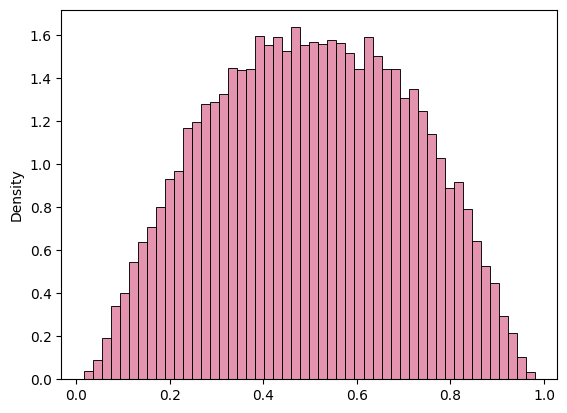

In [50]:
seaborn.histplot(online_preference,                  # данные
                 stat  = 'density',          # тип гистограммы
                 color = "palevioletred",    # цвет гистограммы
                 label = "histogram",        # наименование гистограммы
                 bins  = 50)

гистограмма показывает распределение скрытой склонности к онлайн-покупкам после логистического преобразования. Значения концентрируются около середины шкалы, но сохраняют разброс, достаточный для различий между клиентами.


## Инструментальная переменная

Инструмент `free_trial_banner` показывает, был ли клиенту предложен бесплатный пробный период премиум-подписки. Вероятность показа баннера строится через индекс, зависящий только от наблюдаемых характеристик: дохода, возраста, города и размера семьи.

Формально:

$$Z_i^* = -0.75 + 4\left(0.15 IncomeZ_i + 0.08 Urban_i - 0.07 AgeCenter_i - 0.06(FamilySize_i - 2.5)\right),$$

$$P(Z_i = 1 \mid X_i) = \Phi(Z_i^*), \quad Z_i \sim Bernoulli(\Phi(Z_i^*)).$$

Здесь $\Phi(\cdot)$ - функция распределения стандартного нормального закона. Ненаблюдаемая `online_preference` в индекс инструмента не входит, поэтому содержательно сохраняется условие исключения: баннер должен влиять на траты только через подписку.


## Индекс инструмента и генерация баннера

Следующая ячейка стандартизирует доход и возраст, затем строит индекс `free_trial_banner_index`, переводит его в вероятность через `norm.cdf` и генерирует бинарный инструмент `free_trial_banner`. По консультации желательно, чтобы дисперсия индекса для такой бинарной переменной была сопоставима с дисперсией стандартного нормального распределения и отличалась от нее не более чем в 2 раза.

Формально обозначим вектор наблюдаемых контролей как $X_i = (Income_i, Age_i, Urban_i, FamilySize_i)$. Инструмент задается через условную вероятность

$$P(Z_i = 1 \mid X_i) = \Phi\left(\eta_i^Z\right),$$

где $Z_i$ - `free_trial_banner`, $\Phi(\cdot)$ - функция распределения стандартной нормали, а индекс имеет вид

$$\eta_i^Z = -0.75 + 4 \cdot \left(0.15\,IncomeZ_i + 0.08\,Urban_i - 0.07\,AgeCenter_i - 0.06\,(FamilySize_i - 2.5)\right).$$

После этого фактическое значение инструмента генерируется как

$$Z_i \sim Bernoulli\left(P(Z_i = 1 \mid X_i)\right).$$

Ненаблюдаемая переменная `online_preference` в индекс инструмента не входит. Поэтому инструмент может быть связан с тратами через наблюдаемые характеристики клиентов, но не должен напрямую зависеть от скрытой склонности к онлайн-покупкам.


In [51]:
log_income = np.log(income)
income_z = (log_income - 11.1) / 0.5
age_center = (age - 35) / 10

free_trial_banner_index = (-0.75
                           + 4 * (0.15 * income_z
                                  + 0.08 * urban_area
                                  - 0.07 * age_center
                                  - 0.06 * (family_size - 2.5)))
free_trial_banner_prob = norm.cdf(free_trial_banner_index)
free_trial_banner = np.random.binomial(n = 1, p = free_trial_banner_prob, size = n)


инструмент сгенерирован как бинарная переменная на основе наблюдаемых контролей. Ненаблюдаемая `online_preference` в индекс инструмента не входит, поэтому содержательно сохраняется условие исключения: баннер должен влиять на траты только через подписку.


In [52]:
np.var(free_trial_banner_index)

np.float64(0.5259470366508437)

`Var(free_trial_banner_index) = 0.526`. Для `norm.cdf` ориентиром является дисперсия стандартной нормали, равная 1; по консультации отличие должно быть не более чем в 2 раза. Значение 0.526 попадает в допустимый диапазон примерно от 0.5 до 2.


In [53]:
np.mean(free_trial_banner)

np.float64(0.33886666666666665)

доля единиц в `free_trial_banner` равна `0.339`. По заданию для бинарных переменных доля единиц должна быть не меньше 0.1 и не больше 0.9; это условие выполняется.


## Генерация переменной воздействия

Переменная воздействия `premium_subscription` моделируется через потенциальные исходы подписки: `premium1` при наличии баннера и `premium0` без баннера. В обозначениях:

$$D_i(1) \text{ - подписка при } Z_i=1,$$

$$D_i(0) \text{ - подписка при } Z_i=0.$$

Наблюдаемая подписка выбирается по фактическому значению инструмента:

$$D_i = Z_iD_i(1) + (1-Z_i)D_i(0).$$

Такой способ нужен для дальнейшего расчета групп Always takers, Never takers и Compliers, а также LATE.


## Потенциальные исходы подписки

В следующей ячейке строится нелинейный индекс подписки. На вероятность подписки влияют скрытая склонность к онлайн-покупкам, доход, возраст, город, размер семьи и содержательные взаимодействия между ними. Один и тот же равномерный шум `u` используется для `premium1` и `premium0`, поэтому выполняется монотонность `premium1 >= premium0` и не возникают Defiers.

Формально пусть $U_i \sim Uniform(0, 1)$, а $D_i(z)$ - потенциальное значение переменной воздействия `premium_subscription` при значении инструмента $Z_i=z$. Тогда

$$D_i(1) = I\left(U_i \leq F_{logistic}(\eta_i^D + 0.75 + 0.30\,Segment_i + 0.20\,I(IncomeZ_i > 0.5))\right),$$

$$D_i(0) = I\left(U_i \leq F_{logistic}(\eta_i^D)\right),$$

где $F_{logistic}(\cdot)$ - функция распределения стандартного логистического распределения, а $\eta_i^D$ содержит влияние `online_preference`, дохода, возраста, города, размера семьи и их нелинейных взаимодействий. Наблюдаемая подписка связана с потенциальными значениями так:

$$D_i = Z_iD_i(1) + (1-Z_i)D_i(0).$$

Так как надбавка к индексу при $Z_i=1$ неотрицательна и используется один и тот же $U_i$, для каждого клиента выполняется $D_i(1) \geq D_i(0)$.


## Проверка потенциальных уровней подписки

Следующие ячейки отдельно показывают среднюю долю подписки в потенциальных состояниях с баннером и без баннера, затем классифицируют клиентов по типам реакции на инструмент.


In [54]:
u = uniform.rvs(size = n)
premium_index = (-0.55
                 + 2.8 * (online_preference - 0.5)
                 + 0.22 * income_z
                 + 0.12 * urban_area
                 + 0.10 * (family_size - 2.5)
                 + 0.85 * urban_area * (family_size >= 3)
                 + 0.75 * (income_z > 0.7) * urban_area
                 - 0.75 * (income_z < -0.6) * (1 - urban_area)
                 - 0.65 * ((age - 32) / 13) ** 2
                 + 0.50 * ((age >= 26) & (age <= 38)) * urban_area
                 + 0.45 * ((family_size >= 4) & (income_z > -0.2)))

premium_segment = ((urban_area == 1) & (family_size >= 3)).astype(float)
free_trial_banner1 = 1
premium1_prob = logistic.cdf(premium_index + 0.75 * free_trial_banner1
                             + 0.30 * premium_segment
                             + 0.20 * (income_z > 0.5))
premium1 = (u <= premium1_prob).astype(int)

free_trial_banner0 = 0
premium0_prob = logistic.cdf(premium_index + 0.75 * free_trial_banner0
                             + 0.30 * premium_segment * free_trial_banner0
                             + 0.20 * (income_z > 0.5) * free_trial_banner0)
premium0 = (u <= premium0_prob).astype(int)

premium_subscription = premium1 * free_trial_banner + premium0 * (1 - free_trial_banner)


In [55]:
np.mean(premium1)

np.float64(0.6041)

средняя потенциальная доля подписки при показе баннера равна `0.604`. Баннер заметно повышает вероятность подписки, что соответствует требованию релевантности инструмента.


In [56]:
np.mean(premium0)

np.float64(0.437)

средняя потенциальная доля подписки без баннера равна `0.437`. Разница между `premium1` и `premium0` означает, что в данных есть группа клиентов, реагирующих на инструмент.


In [57]:
ind_type = np.empty(n, dtype = 'U25')
ind_type[(premium1 == 1) & (premium0 == 1)] = 'Always taker'
ind_type[(premium1 == 0) & (premium0 == 0)] = 'Never taker'
ind_type[premium1 > premium0] = 'Complier'
ind_type[premium1 < premium0] = 'Denier'
pd.Series(ind_type).value_counts()


Always taker    13110
Never taker     11877
Complier         5013
Name: count, dtype: int64

получаются Always takers, Never takers и Compliers, а Defiers отсутствуют. Это соответствует монотонности, которая важна для дальнейшей интерпретации LATE.


In [58]:
premium_subscription = premium1 * free_trial_banner + premium0 * (1 - free_trial_banner)
np.mean(premium_subscription)

np.float64(0.4940333333333333)

наблюдаемая доля подписки равна `0.494`, то есть классы почти сбалансированы. Требование задания для бинарных переменных также выполняется: значение находится между 0.1 и 0.9.


## Проверка ключевых связей

Следующая ячейка проверяет две связи, которые важны по консультации:

$$Corr(D_i, OnlinePreference_i)$$

и

$$Corr(D_i, Z_i).$$

Желательный диапазон для обеих корреляций: от 0.2 до 0.8 по модулю. Первая связь подтверждает существенную эндогенность, вторая - релевантность инструмента.


In [59]:
print(pd.DataFrame(data    = [np.corrcoef(premium_subscription, online_preference)[0, 1],
                              np.corrcoef(premium_subscription, free_trial_banner)[0, 1]],
                   index   = ['Corr(premium_subscription, online_preference)',
                              'Corr(premium_subscription, free_trial_banner)'],
                   columns = ['Оценка']))

                                                 Оценка
Corr(premium_subscription, online_preference)  0.219636
Corr(premium_subscription, free_trial_banner)  0.225888


`Corr(premium_subscription, online_preference)=0.220`, а `Corr(premium_subscription, free_trial_banner)=0.226`. Оба значения попадают в рекомендованный консультацией диапазон 0.2-0.8 по модулю: эндогенность существенная, а инструмент релевантен, но не является почти детерминированным предиктором подписки.


## Генерация зависимой переменной

Зависимая переменная `monthly_spending` строится через потенциальные исходы `monthly_spending0` и `monthly_spending1`. Каждый потенциальный исход состоит из наблюдаемой компоненты, ненаблюдаемой компоненты и случайной ошибки. Это соответствует заданию: нужно математически описать потенциальные исходы зависимой переменной и связь с наблюдаемым значением.

Формально потенциальные месячные траты задаются как

$$Y_i(0) = \max\left(1, g_{0i}^{obs}(X_i) + g_{0i}^{unobs}(OnlinePreference_i) + \varepsilon_{0i}\right),$$

$$Y_i(1) = \max\left(1, g_{1i}^{obs}(X_i) + g_{1i}^{unobs}(OnlinePreference_i) + \varepsilon_{1i}\right),$$

где $Y_i(0)$ - траты без премиум-подписки, $Y_i(1)$ - траты при наличии премиум-подписки. Нижняя граница равна 1, чтобы траты оставались положительными и в дальнейшем можно было корректно использовать MAPE в регрессионном блоке. Наблюдаемая зависимая переменная определяется фактическим воздействием:

$$Y_i = D_iY_i(1) + (1-D_i)Y_i(0).$$


## Случайные ошибки

Следующая ячейка задает ошибки для двух режимов: без подписки и с подпиской:

$$\varepsilon_{0i} \sim 1600 \cdot t(10),$$

$$\varepsilon_{1i} \sim 2200 \cdot t(8).$$

Масштабы ошибок подобраны так, чтобы случайная часть не доминировала над структурной частью и не была пренебрежимо малой.


## Структурные компоненты трат

Далее задаются наблюдаемые и ненаблюдаемые компоненты потенциальных трат. Для каждого режима $j \in \{0,1\}$ используется разложение:

$$g_{ji} = g_{ji}^{obs}(X_i) + g_{ji}^{unobs}(OnlinePreference_i).$$

Для режима без подписки:

$$Y_i(0) = \max(1, g_{0i} + \varepsilon_{0i}).$$

Для режима с подпиской:

$$Y_i(1) = \max(1, g_{1i} + \varepsilon_{1i}), \quad g_{1i}^{obs}(X_i) = g_{0i}^{obs}(X_i) + \tau_i(X_i, OnlinePreference_i).$$

Здесь $\tau_i$ - гетерогенный структурный эффект подписки. Он выше для городских клиентов, семей с большим размером, клиентов с высоким доходом и клиентов активного возраста. Поэтому DGP является нелинейным и допускает неодинаковые индивидуальные эффекты воздействия.

По консультации для каждого режима $j = 0, 1$ дисперсии $\varepsilon_j$, $g_j$, $g_j^{obs}$ и $g_j^{unobs}$ должны отличаться не более чем в 5 раз; это проверяется ниже отдельной таблицей.


In [60]:
error0 = t.rvs(size = n, df = 10) * 1600
error1 = t.rvs(size = n, df = 8) * 2200


ошибки имеют сопоставимый масштаб с экономическими компонентами трат. Окончательно это проверяется ниже через таблицу дисперсий.


In [61]:
base_spending = (4800
                 + 1250 * income_z
                 + 850 * urban_area
                 + 650 * (family_size - 2)
                 - 280 * (age_center ** 2)
                 + 650 * urban_area * (family_size - 2)
                 + 1400 * np.maximum(income_z, 0) * urban_area
                 + 650 * ((age >= 25) & (age <= 40)) * urban_area)
g0_obs = base_spending
g0_unobs = 1.25 * (1600 * (online_preference - 0.5) + 800 * online_preference_raw)
g0 = g0_obs + g0_unobs


для режима без подписки траты зависят от дохода, города, размера семьи, возраста и скрытой онлайн-склонности. Ненаблюдаемая часть нужна, чтобы пропуск `online_preference` создавал эндогенность в последующих моделях.


In [62]:
treatment_effect_structural = (3900
                               + 950 * urban_area
                               + 800 * (family_size - 2)
                               + 900 * np.maximum(income_z, 0)
                               + 700 * online_preference
                               + 700 * urban_area * (family_size >= 3)
                               + 700 * ((age >= 25) & (age <= 40)) * urban_area
                               + 500 * (income_z > 0.8))
g1_obs = base_spending + treatment_effect_structural
g1_unobs = 2.5 * (2200 * (online_preference - 0.5) + 800 * online_preference_raw)
g1 = g1_obs + g1_unobs


для режима с подпиской добавляется гетерогенный структурный эффект подписки. Эффект выше для городских клиентов, семей, клиентов с большим доходом и клиентов активного возраста, что делает DGP нелинейным и содержательно отличным от простой линейной модели.


In [63]:
monthly_spending0 = g0 + error0
monthly_spending1 = g1 + error1
monthly_spending0[monthly_spending0 < 1] = 1
monthly_spending1[monthly_spending1 < 1] = 1

monthly_spending = monthly_spending1 * premium_subscription + monthly_spending0 * (1 - premium_subscription)

наблюдаемые месячные траты выбираются из потенциальных исходов по фактическому значению подписки. Значения меньше 1 обрезаются на уровне 1, чтобы переменная трат оставалась экономически осмысленной и не содержала нулей. Это важно для последующего регрессионного блока, где используется MAPE.

## Проверка адекватности симуляции

Следующая таблица проверяет дисперсии случайных ошибок и структурных частей модели. Для соответствия консультации внутри каждого режима $j = 0$ и $j = 1$ должно выполняться:

$$\frac{\max\{Var(\varepsilon_j), Var(g_j), Var(g_j^{obs}), Var(g_j^{unobs})\}}{\min\{Var(\varepsilon_j), Var(g_j), Var(g_j^{obs}), Var(g_j^{unobs})\}} \leq 5.$$

Это условие нужно, чтобы зависимая переменная не определялась почти полностью ни шумом, ни одной структурной компонентой.


In [64]:
x = pd.DataFrame(data    = [np.var(error0),   np.var(g0),
                              np.var(g0_obs),   np.var(g0_unobs),
                              np.var(error1),   np.var(g1),
                              np.var(g1_obs),   np.var(g1_unobs)],
                   index   = ['Var(eps0)',     'Var(g0)',
                              'Var(g0_obs)',   'Var(g0_unobs)',
                              'Var(eps1)',     'Var(g1)',
                              'Var(g1_obs)',   'Var(g1_unobs)'],
                   columns = ['Оценка'])

x.round(2)

,Оценка
Var(eps0),3215423.29
Var(g0),8102296.06
Var(g0_obs),6057026.86
Var(g0_unobs),1995028.55
Var(eps1),6610986.11
Var(g1),26229339.87
Var(g1_obs),15271512.63
Var(g1_unobs),9832761.73


для `j=0` отношение максимальной дисперсии к минимальной равно `4.061`, для `j=1` — `3.968`. Оба значения меньше 5, значит требование консультации о сопоставимости дисперсий внутри группы выполняется.


In [65]:
df = pd.DataFrame({
    "monthly_spending": monthly_spending,
    "premium_subscription": premium_subscription,
    "income": income,
    "age": age,
    "urban_area": urban_area,
    "family_size": family_size,
    "free_trial_banner": free_trial_banner
})
df = df.loc[0:n, :]

в итоговый датасет включены только наблюдаемые переменные. Скрытая `online_preference` и потенциальные исходы не попадают в `df`, что важно для последующих блоков классификации, регрессии и оценки эффектов.


In [66]:
df

,monthly_spending,premium_subscription,income,age,urban_area,family_size,free_trial_banner
0,11721.117830,1,38452.719412,24.0,1,2,0
1,10911.269377,1,108953.092363,27.0,1,2,1
2,8642.447791,0,76228.390348,53.0,1,1,0
3,1.000000,0,31158.820400,52.0,1,1,0
4,7228.550018,0,49548.133698,48.0,0,3,0
...,...,...,...,...,...,...,...
29995,1.000000,0,32398.252341,40.0,1,2,0
29996,9199.842091,0,82063.661741,38.0,1,3,0
29997,13807.331047,1,37333.159454,22.0,0,3,0
29998,11423.438625,1,52216.780118,31.0,1,2,0


просмотр `df` подтверждает структуру итоговой таблицы: одна зависимая переменная, одна переменная воздействия, четыре контрольные переменные и один инструмент.


## Задание 2.2

Симулируйте данные в соответствии с предполагаемым процессом и приведите корреляционную матрицу, а также таблицу с описательными статистиками: для непрерывных переменных - выборочное среднее, стандартное отклонение, медиану, минимум и максимум; для бинарных переменных - долю и количество единиц. Необходимо сгенерировать не менее 1000 наблюдений, а доля единиц не должна быть меньше 0.1 или больше 0.9 ни для одной бинарной переменной.

### Ответ

После генерации все наблюдаемые переменные объединяются в `df`:

$$df_i = (Y_i, D_i, Income_i, Age_i, Urban_i, FamilySize_i, Z_i).$$

Ненаблюдаемая `online_preference`, потенциальные исходы $Y_i(0)$, $Y_i(1)$, $D_i(0)$ и $D_i(1)$ не включаются в итоговый датасет как признаки. Ниже выполняются требуемые проверки: описательные статистики для непрерывных переменных, доли и количества единиц для бинарных переменных, соответствие распределения `family_size`, связь инструмента с подпиской и корреляционная матрица.


In [67]:
df.describe().round(2)

,monthly_spending,premium_subscription,income,age,urban_area,family_size,free_trial_banner
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,9952.12,0.49,75206.02,35.21,0.70,2.49,0.34
std,6539.10,0.50,40050.14,9.61,0.46,1.12,0.47
min,1.00,0.00,9890.31,18.00,0.00,1.00,0.00
25%,4757.59,0.00,47285.73,28.00,0.00,2.00,0.00
50%,8478.69,0.00,66396.19,35.00,1.00,2.00,0.00
75%,14642.53,1.00,92902.68,42.00,1.00,3.00,1.00
max,36871.00,1.00,505876.81,70.00,1.00,5.00,1.00


таблица `describe` дает требуемые заданием описательные статистики для непрерывных переменных: среднее, стандартное отклонение, медиану, минимум и максимум. Для бинарных переменных доли проверяются отдельно ниже.


<Axes: >

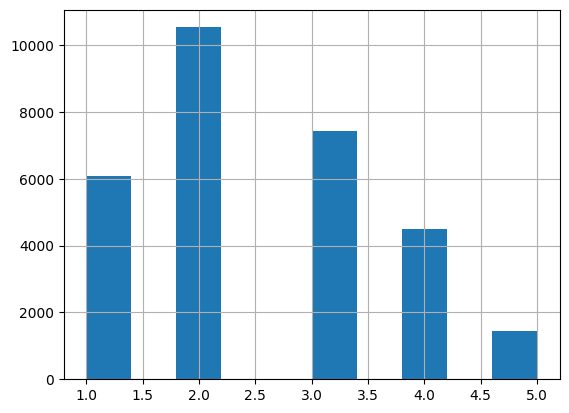

In [68]:
df['family_size'].hist()

распределение `family_size` визуально соответствует заданным вероятностям: чаще встречаются семьи из двух и трех человек, реже — семьи из пяти человек.


<Axes: >

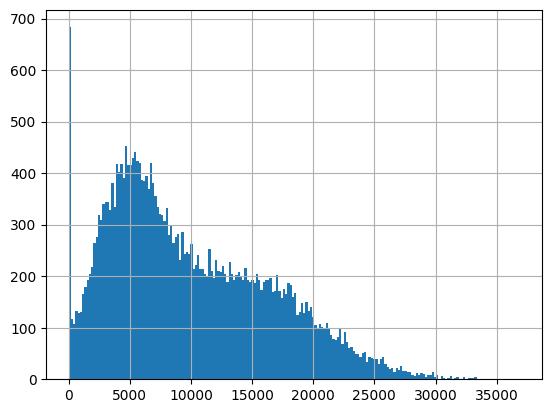

In [69]:
df['monthly_spending'].hist(bins=200)

распределение `monthly_spending` имеет правый хвост, что естественно для денежных трат: большинство клиентов тратит умеренно, но есть клиенты с высокими расходами.


<Axes: >

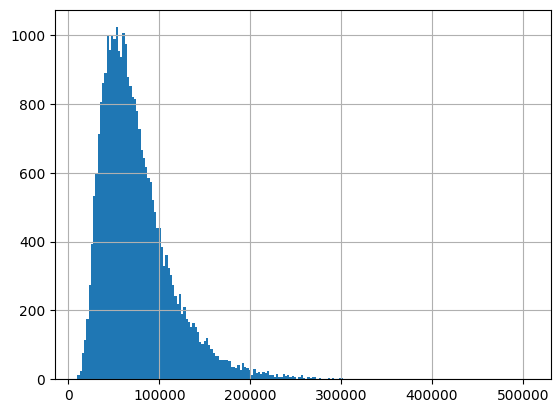

In [70]:
df['income'].hist(bins=200)

распределение `income` правосторонне асимметрично, что соответствует логнормальной генерации дохода и экономической интерпретации переменной.


<Axes: >

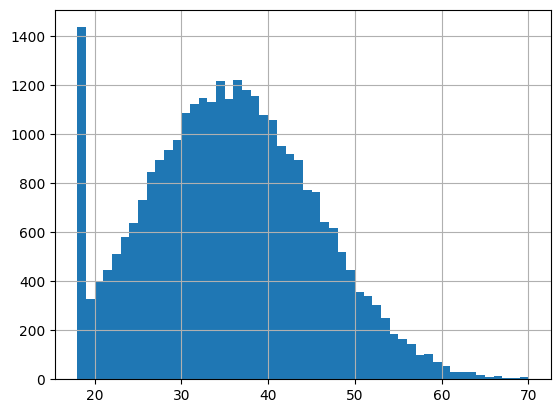

In [71]:
df['age'].hist(bins=52)

возраст ограничен диапазоном от 18 до 70 лет, поэтому значения остаются реалистичными для клиентов сервиса доставки.


In [72]:
binary_check = pd.DataFrame({
    'count_ones': [int(np.sum(premium_subscription)),
                   int(np.sum(free_trial_banner)),
                   int(np.sum(urban_area))],
    'share_ones': [np.mean(premium_subscription),
                   np.mean(free_trial_banner),
                   np.mean(urban_area)],
    'requirement_min': [0.10, 0.10, 0.10],
    'requirement_max': [0.90, 0.90, 0.90]
}, index = ['premium_subscription', 'free_trial_banner', 'urban_area'])

binary_check['passes_requirement'] = binary_check['share_ones'].between(
    binary_check['requirement_min'],
    binary_check['requirement_max']
)
binary_check


,count_ones,share_ones,requirement_min,requirement_max,passes_requirement
premium_subscription,14821,0.494033,0.1,0.9,True
free_trial_banner,10166,0.338867,0.1,0.9,True
urban_area,21044,0.701467,0.1,0.9,True


таблица показывает долю и количество единиц для всех бинарных переменных: `premium_subscription`, `free_trial_banner` и `urban_area`. Все три доли находятся в диапазоне от 0.1 до 0.9, поэтому ограничение задания для бинарных переменных выполняется.


In [73]:
family_target = pd.Series({1: 0.20, 2: 0.35, 3: 0.25, 4: 0.15, 5: 0.05}, name = 'target')
family_actual = pd.Series(family_size).value_counts(normalize = True).sort_index()
family_check = pd.concat([family_target, family_actual.rename('actual')], axis = 1)
family_check['abs_diff'] = np.abs(family_check['actual'] - family_check['target'])
family_check

,target,actual,abs_diff
1,0.20,0.202967,0.002967
2,0.35,0.351233,0.001233
3,0.25,0.247633,0.002367
4,0.15,0.149567,0.000433
5,0.05,0.048600,0.001400


фактическое распределение `family_size` близко к заданным вероятностям. Небольшие отклонения являются обычной выборочной вариацией при случайной генерации.


In [74]:
premium_by_banner = pd.crosstab(free_trial_banner,
                              premium_subscription,
                              normalize = 'index').rename(columns = {0: 'premium_0', 1: 'premium_1'})
premium_by_banner

col_0,premium_0,premium_1
row_0,,
0,0.586821,0.413179
1,0.348220,0.651780


таблица показывает релевантность инструмента на уровне условных вероятностей: `P(D=1|Z=1)=0.652` выше, чем `P(D=1|Z=0)=0.413`. Баннер повышает вероятность подписки, но не делает ее детерминированной.


In [75]:
type_table = pd.Series(ind_type).value_counts().to_frame('count')
type_table['share'] = type_table['count'] / n
type_table

,count,share
Always taker,13110,0.4370
Never taker,11877,0.3959
Complier,5013,0.1671


в выборке есть Compliers (`16.7%`), для которых инструмент меняет статус подписки. Defiers отсутствуют, поэтому монотонность для LATE выполняется.


In [76]:
corr_table = pd.DataFrame(data = [np.corrcoef(premium_subscription, online_preference)[0, 1],
                                        np.corrcoef(premium_subscription, free_trial_banner)[0, 1]],
                          index = ['Corr(premium_subscription, online_preference)',
                                     'Corr(premium_subscription, free_trial_banner)'],
                          columns = ['estimate'])
corr_table

,estimate
"Corr(premium_subscription, online_preference)",0.219636
"Corr(premium_subscription, free_trial_banner)",0.225888


обе корреляции из таблицы находятся в диапазоне 0.2-0.8 по модулю. Значит, связь подписки со скрытой переменной достаточно сильна для эндогенности, а связь с инструментом достаточна для релевантности.


In [77]:
var_table = pd.DataFrame(data = [np.var(error0),   np.var(g0),
                                       np.var(g0_obs), np.var(g0_unobs),
                                       np.var(error1), np.var(g1),
                                       np.var(g1_obs), np.var(g1_unobs)],
                         index = ['Var(eps0)',   'Var(g0)',
                                    'Var(g0_obs)', 'Var(g0_unobs)',
                                    'Var(eps1)',   'Var(g1)',
                                    'Var(g1_obs)', 'Var(g1_unobs)'],
                         columns = ['estimate'])
var_table.round(2)

,estimate
Var(eps0),3215423.29
Var(g0),8102296.06
Var(g0_obs),6057026.86
Var(g0_unobs),1995028.55
Var(eps1),6610986.11
Var(g1),26229339.87
Var(g1_obs),15271512.63
Var(g1_unobs),9832761.73


эта таблица дублирует детальную проверку дисперсий для итогового контроля. По расчету выше отношение max/min внутри каждого режима меньше 5, поэтому консультационное ограничение выполняется.


In [78]:
spending_checks = pd.DataFrame({
    'metric': ['share_min_monthly_spending0', 'share_min_monthly_spending1',
               'share_zero_monthly_spending', 'min_monthly_spending', 'mean_monthly_spending'],
    'value': [np.mean(monthly_spending0 == 1), np.mean(monthly_spending1 == 1),
              np.mean(monthly_spending == 0), np.min(monthly_spending), np.mean(monthly_spending)]
})
spending_checks

,metric,value
0,share_min_monthly_spending0,0.021733
1,share_min_monthly_spending1,0.009233
2,share_zero_monthly_spending,0.000000
3,min_monthly_spending,1.000000
4,mean_monthly_spending,9952.123756


доля потенциальных трат, обрезанных на нижней границе 1, невелика: около `2.17%` для `monthly_spending0` и `0.92%` для `monthly_spending1`. В наблюдаемой зависимой переменной нет нулей, а минимальное значение равно 1, поэтому последующее вычисление MAPE не будет сталкиваться с делением на ноль.

In [79]:
TE = monthly_spending1 - monthly_spending0
ATE = np.mean(TE)
LATE = np.mean(TE[ind_type == "Complier"])
CATE = g1 - g0
ATE_naive = np.mean(monthly_spending[premium_subscription == 1]) - np.mean(monthly_spending[premium_subscription == 0])

effect_table = pd.DataFrame({'estimate': [ATE, LATE, np.mean(CATE), ATE_naive]
                }, index = ['ATE', 'LATE', 'mean(CATE)', 'ATE_naive'])
effect_table.round(2)

,estimate
ATE,6292.96
LATE,6280.32
mean(CATE),6279.19
ATE_naive,9760.32


Истинный `ATE` равен примерно `6293`, `LATE` - примерно `6280`, а наивная разница средних - примерно `9760`. Наивная оценка выше истинного эффекта, что подтверждает наличие самоотбора в подписку.

Используемые величины определяются так:

$$TE_i = Y_i(1) - Y_i(0),$$

$$ATE = E[Y_i(1) - Y_i(0)],$$

$$LATE = E[Y_i(1) - Y_i(0) \mid D_i(1) > D_i(0)],$$

$$ATE_{naive} = E[Y_i \mid D_i=1] - E[Y_i \mid D_i=0].$$


In [80]:
df.isna().mean() * 100

monthly_spending        0.0
premium_subscription    0.0
income                  0.0
age                     0.0
urban_area              0.0
family_size             0.0
free_trial_banner       0.0
dtype: float64

доля пропусков по всем переменным равна нулю, поэтому дополнительная обработка missing values перед следующими блоками не требуется.


## Корреляционная матрица

Следующая ячейка строит корреляционную матрицу по наблюдаемым переменным итогового датасета. Она используется как первичная диагностика структуры данных: по ней видно, связаны ли инструмент, воздействие, траты и контрольные переменные.


In [81]:
df.corr().round(3)

,monthly_spending,premium_subscription,income,age,urban_area,family_size,free_trial_banner
monthly_spending,1.000,0.746,0.432,-0.095,0.302,0.350,0.200
premium_subscription,0.746,1.000,0.229,-0.137,0.213,0.146,0.226
income,0.432,0.229,1.000,-0.002,-0.002,-0.002,0.370
age,-0.095,-0.137,-0.002,1.000,-0.008,-0.002,-0.161
urban_area,0.302,0.213,-0.002,-0.008,1.000,-0.006,0.090
family_size,0.350,0.146,-0.002,-0.002,-0.006,1.000,-0.176
free_trial_banner,0.200,0.226,0.370,-0.161,0.090,-0.176,1.000


корреляционная матрица используется как описательная диагностика, а не как доказательство причинности. Для причинной интерпретации далее нужны потенциальные исходы, инструмент и методы оценки эффектов.


## Задание 2.3

Разделите выборку на обучающую и тестовую. Тестовая выборка должна включать от 20% до 30% наблюдений.

### Ответ

Следующая ячейка делит выборку на обучающую и тестовую в пропорции 75/25. По заданию тестовая выборка должна составлять от 20% до 30% наблюдений; значение 25% попадает в этот диапазон.


In [82]:
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, test_size=0.25, random_state=123)

тестовая выборка составляет 25% наблюдений, то есть попадает в требуемый диапазон 20-30%. Фиксированный `random_state` делает разбиение воспроизводимым.


## Сохранение данных

Следующая ячейка сохраняет полный датасет, обучающую выборку и тестовую выборку в CSV-файлы, чтобы следующие блоки проекта использовали ту же сгенерированную выборку.


In [83]:
df_full = df.copy()
df_full['income_z'] = income_z
df_full['age_center'] = age_center
df_full['online_preference_raw'] = online_preference_raw
df_full['online_preference'] = online_preference
df_full['free_trial_banner_index'] = free_trial_banner_index
df_full['free_trial_banner_prob'] = free_trial_banner_prob
df_full['premium_index'] = premium_index
df_full['premium_segment'] = premium_segment
df_full['premium1_prob'] = premium1_prob
df_full['premium0_prob'] = premium0_prob
df_full['premium1'] = premium1
df_full['premium0'] = premium0
df_full['ind_type'] = ind_type
df_full['error0'] = error0
df_full['error1'] = error1
df_full['base_spending'] = base_spending
df_full['g0_obs'] = g0_obs
df_full['g0_unobs'] = g0_unobs
df_full['g0'] = g0
df_full['treatment_effect_structural'] = treatment_effect_structural
df_full['g1_obs'] = g1_obs
df_full['g1_unobs'] = g1_unobs
df_full['g1'] = g1
df_full['monthly_spending0'] = monthly_spending0
df_full['monthly_spending1'] = monthly_spending1
df_full['TE'] = monthly_spending1 - monthly_spending0
df_full['CATE'] = g1 - g0

df_full_train = df_full.loc[df_train.index]
df_full_test = df_full.loc[df_test.index]

df.to_csv("df.csv", index=False)
df_train.to_csv("df_train.csv", index=False)
df_test.to_csv("df_test.csv", index=False)
df_full.to_csv("df_full.csv", index=False)
df_full_train.to_csv("df_full_train.csv", index=False)
df_full_test.to_csv("df_full_test.csv", index=False)

файлы `df.csv`, `df_train.csv` и `df_test.csv` фиксируют текущую версию генерации для следующих ноутбуков проекта.


## Задание 2.4

В случае необходимости проведите дополнительный анализ и приведите дополнительные комментарии о процессе генерации данных, описательных статистиках и т.д.

### Ответ

Следующая таблица собирает основные sanity checks: баланс подписки и баннера, релевантность инструмента, эндогенность через скрытую переменную и сравнение истинных эффектов с наивной оценкой.

Ключевые условия:

$$0.1 \leq P(D_i=1), P(Z_i=1), P(Urban_i=1) \leq 0.9,$$

$$0.2 \leq |Corr(D_i, Z_i)| \leq 0.8,$$

$$0.2 \leq |Corr(D_i, OnlinePreference_i)| \leq 0.8.$$

Эта таблица нужна, чтобы быстро проверить соответствие генерации заданию и консультации.


In [84]:
generation_diagnostic = pd.DataFrame({
    'metric': ['share_premium_subscription', 'share_free_trial_banner', 'share_urban_area',
               'Corr(D, Z)', 'Corr(D, online_preference)',
               'P(D=1 | Z=0)', 'P(D=1 | Z=1)',
               'ATE', 'LATE', 'ATE_naive'],
    'value': [np.mean(premium_subscription), np.mean(free_trial_banner), np.mean(urban_area),
              np.corrcoef(premium_subscription, free_trial_banner)[0, 1],
              np.corrcoef(premium_subscription, online_preference)[0, 1],
              np.mean(premium_subscription[free_trial_banner == 0]),
              np.mean(premium_subscription[free_trial_banner == 1]),
              ATE, LATE, ATE_naive]
})
generation_diagnostic.round(3)


,metric,value
0,share_premium_subscription,0.494
1,share_free_trial_banner,0.339
2,share_urban_area,0.701
3,"Corr(D, Z)",0.226
4,"Corr(D, online_preference)",0.220
5,P(D=1 | Z=0),0.413
6,P(D=1 | Z=1),0.652
7,ATE,6292.960
8,LATE,6280.319
9,ATE_naive,9760.320


итоговая таблица подтверждает три ключевых условия: бинарные доли находятся в диапазоне 0.1-0.9, корреляции `Corr(D, Z)` и `Corr(D, online_preference)` попадают в диапазон 0.2-0.8, а наивная оценка отличается от истинного эффекта из-за эндогенного выбора подписки.


## Интерпретация итоговой диагностики

Доля подписки равна `0.494`, доля баннера — `0.339`, доля города — `0.701`; все бинарные переменные попадают в требуемый заданием диапазон от 0.1 до 0.9. Инструмент релевантен: `Corr(D, Z)=0.226`, а `P(D=1|Z=0)=0.413` и `P(D=1|Z=1)=0.652`. Эндогенность также находится в нормальном диапазоне из консультации: `Corr(D, online_preference)=0.220`, то есть значение попадает в интервал 0.2-0.8. Наивная оценка эффекта (`9760.3`) заметно выше истинного `ATE=6293.0`, поэтому в данных есть содержательный самоотбор, который затем можно обсуждать в блоке эффектов воздействия.
